In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.signal import stft
import os

from funciones.cargador import obtener_una_muestra, DATA_DIR

In [2]:
def detector_entropia_ciego(iq_tensor: torch.Tensor, fs: float = 14e6, nperseg: int = 1024):
    """
    Detector ciego basado en Entropía Espectral de Shannon.
    No requiere conocer la modulación, ancho de banda ni frecuencia central de la señal.
    """
    # 1. Extracción y conversión a complejo
    i_np = iq_tensor[0].numpy()
    q_np = iq_tensor[1].numpy()
    signal_complex = i_np + 1j * q_np
    
    # 2. Espectrograma de alta resolución temporal
    # nperseg define el trade-off: 1024 a 14MHz da ~73 microsegundos por salto
    f, t, Zxx = stft(signal_complex, fs=fs, nperseg=nperseg, return_onesided=False)
    
    # 3. Densidad de Potencia (Magnitud al cuadrado)
    Pxx = np.abs(Zxx)**2
    
    # 4. Normalización a Distribución de Probabilidad (por cada instante de tiempo)
    suma_potencia = np.sum(Pxx, axis=0)
    # Evitamos divisiones por cero en zonas de silencios absolutos del SDR
    suma_potencia[suma_potencia == 0] = 1e-12 
    prob_dist = Pxx / suma_potencia
    
    # Evitamos log(0) sumando un epsilon
    prob_dist = prob_dist + 1e-12
    
    # 5. Cálculo de la Entropía de Shannon H(t) = - sum(p * log2(p))
    entropia = -np.sum(prob_dist * np.log2(prob_dist), axis=0)
    
    return t * 1000, entropia  # Devolvemos tiempo en ms y la entropía

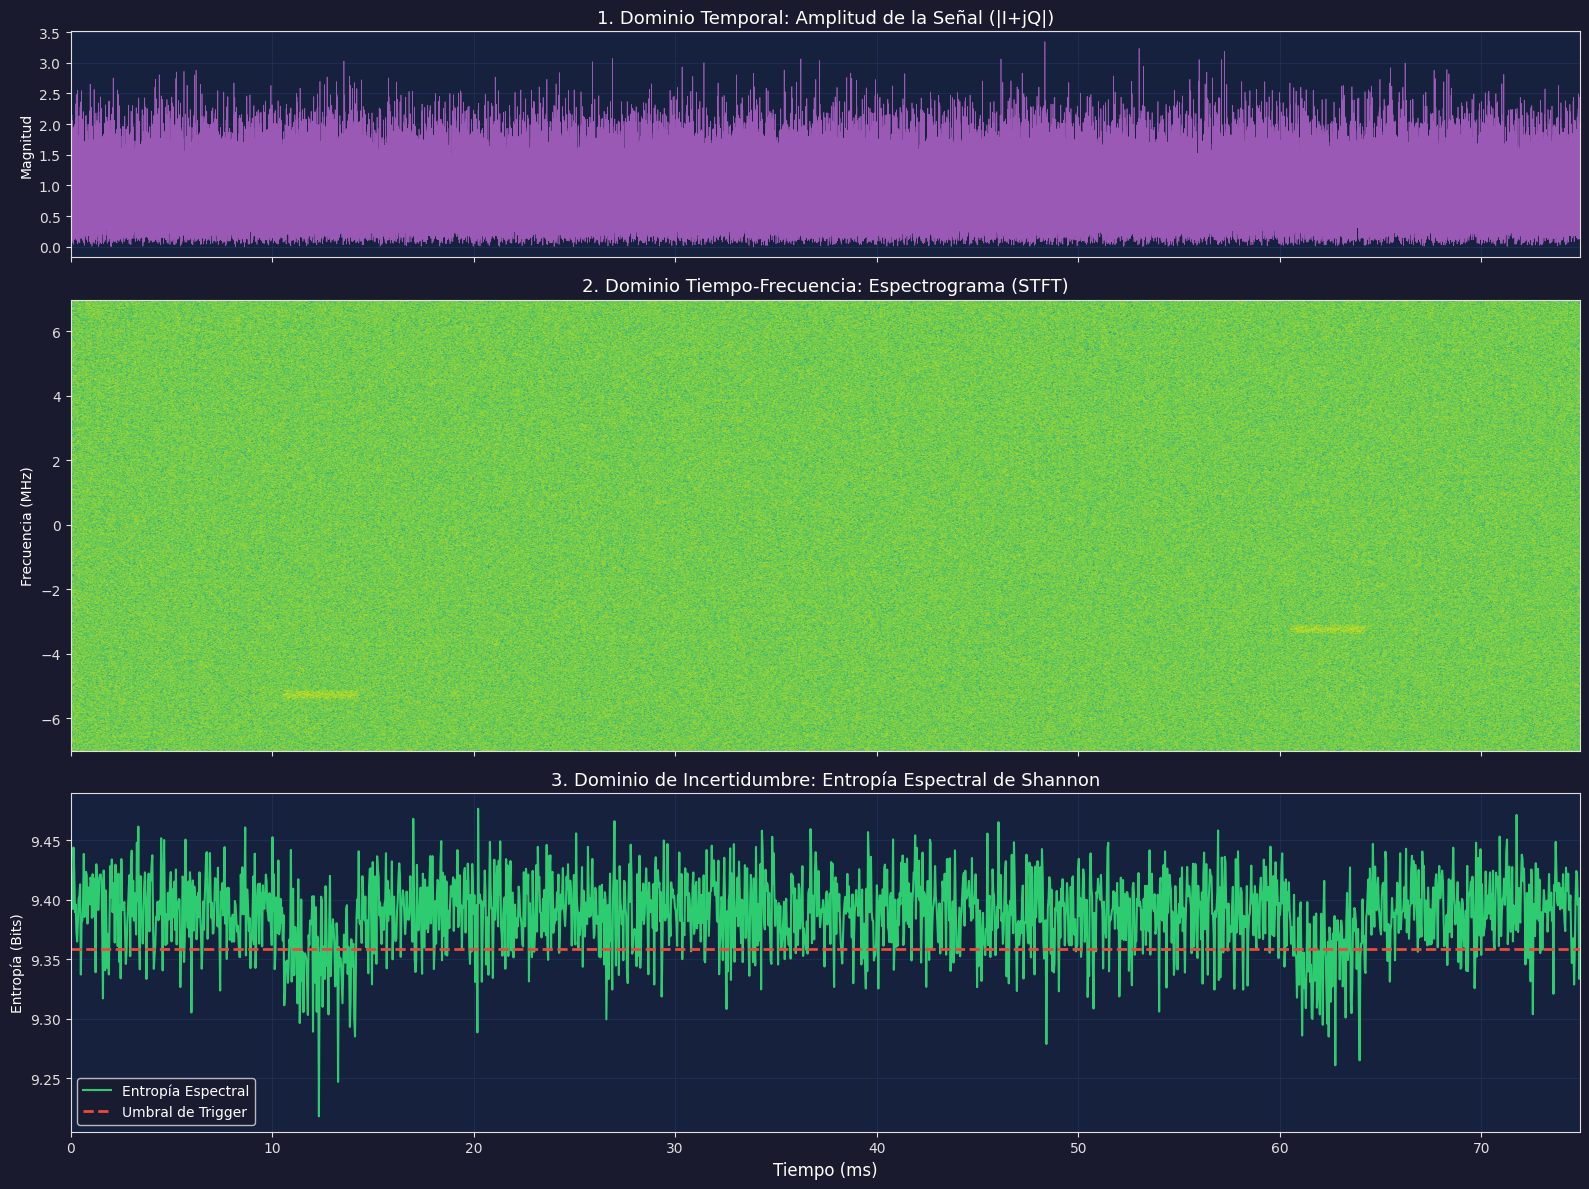

In [26]:
# 1. CARGA DE LA MUESTRA
# Usamos la misma muestra que te generó la gráfica anterior
iq_dron, _, _, _ = obtener_una_muestra(DATA_DIR, target=3, snr=-14, index=12)

# 2. PROCESAMIENTO MULTI-DOMINIO
fs = 14e6
i_np = iq_dron[0].numpy()
q_np = iq_dron[1].numpy()
signal_complex = i_np + 1j * q_np

# A) Dominio Temporal: Envolvente de Amplitud
amplitud = np.abs(signal_complex)
tiempo_amp_ms = np.arange(len(amplitud)) / fs * 1000

# B) Dominio Tiempo-Frecuencia: STFT (Espectrograma)
nperseg = 1024
f, t, Zxx = stft(signal_complex, fs=fs, nperseg=nperseg, return_onesided=False)

# Reordenamos las frecuencias para centrar el DC en el espectrograma (de -fs/2 a fs/2)
f_shifted = np.fft.fftshift(f)
Zxx_shifted = np.fft.fftshift(Zxx, axes=0)

Pxx_db = 10 * np.log10(np.abs(Zxx_shifted)**2 + 1e-12)
tiempo_stft_ms = t * 1000

# C) Dominio de Incertidumbre: Entropía Espectral de Shannon
Pxx_orig = np.abs(Zxx)**2
suma_potencia = np.sum(Pxx_orig, axis=0)
suma_potencia[suma_potencia == 0] = 1e-12 

prob_dist = Pxx_orig / suma_potencia
prob_dist = prob_dist + 1e-12
entropia = -np.sum(prob_dist * np.log2(prob_dist), axis=0)

# 3. VISUALIZACIÓN SIGINT 3-PANEL
plt.style.use('dark_background')
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 12), sharex=True, 
                                    gridspec_kw={'height_ratios': [1, 2, 1.5]})
fig.patch.set_facecolor('#1a1a2e')

for ax in [ax1, ax2, ax3]:
    ax.set_facecolor('#16213e')
    ax.tick_params(colors='#e0e0e0')
    for spine in ax.spines.values(): spine.set_color('#e0e0e0')

# Panel 1: Amplitud (Submuestreamos x10 para acelerar el renderizado sin perder visualización)
step = 10
ax1.plot(tiempo_amp_ms[::step], amplitud[::step], color='#9b59b6', linewidth=0.5)
ax1.set_title('1. Dominio Temporal: Amplitud de la Señal (|I+jQ|)', color='white', fontsize=13)
ax1.set_ylabel('Magnitud', color='white')
ax1.grid(color='#2c3e6b', alpha=0.4)

# Panel 2: Espectrograma
mesh = ax2.pcolormesh(tiempo_stft_ms, f_shifted / 1e6, Pxx_db, shading='gouraud', cmap='viridis')
ax2.set_title('2. Dominio Tiempo-Frecuencia: Espectrograma (STFT)', color='white', fontsize=13)
ax2.set_ylabel('Frecuencia (MHz)', color='white')

# Panel 3: Entropía Espectral
ax3.plot(tiempo_stft_ms, entropia, color='#2ecc71', linewidth=1.5, label='Entropía Espectral')
umbral = np.median(entropia) - np.std(entropia)
ax3.axhline(y=umbral, color='#e74c3c', linestyle='--', linewidth=2, label='Umbral de Trigger')
ax3.set_title('3. Dominio de Incertidumbre: Entropía Espectral de Shannon', color='white', fontsize=13)
ax3.set_xlabel('Tiempo (ms)', color='white', fontsize=12)
ax3.set_ylabel('Entropía (Bits)', color='white')
ax3.grid(color='#2c3e6b', alpha=0.4)
ax3.legend(facecolor='#1a1a2e', edgecolor='#e0e0e0', labelcolor='white')

plt.tight_layout()
plt.show()

# Prueba multiescala

In [27]:
def detector_entropia_multiscala(iq_tensor: torch.Tensor, fs: float = 14e6):
    """
    Detector de transmisión basado en Entropía Espectral Multiscala.
    
    Calcula la entropía en 3 resoluciones temporales simultáneas y toma
    el mínimo frame a frame. Inspirado en MDE (Liu et al., 2026).
    
    Escalas:
      - Gruesa  (nperseg=4096): ~290 µs/frame → detecta bursts largos (WiFi)
      - Media   (nperseg=1024): ~ 73 µs/frame → FHSS estándar (tu versión actual)
      - Fina    (nperseg=256 ): ~ 18 µs/frame → pulsos cortos y transitorios
    
    Returns:
        t_ms   : array de tiempos en ms (resolución de la escala media)
        H_min  : entropía mínima entre las 3 escalas (el trigger más sensible)
        H_all  : dict con las 3 curvas individuales para visualización
    """
    ESCALAS = {
        "gruesa": 4096,
        "media":  1024,
        "fina":   256,
    }
    
    signal = iq_tensor[0].numpy() + 1j * iq_tensor[1].numpy()
    curvas = {}
    for nombre, nperseg in ESCALAS.items():
        _, t, Zxx = stft(signal, fs=fs, nperseg=nperseg, return_onesided=False)
        Pxx  = np.abs(Zxx) ** 2
        suma = Pxx.sum(axis=0)
        suma[suma == 0] = 1e-12
        prob = Pxx / suma + 1e-12
        H    = -(prob * np.log2(prob)).sum(axis=0)
        curvas[nombre] = (t * 1000, H)
    # Interpolamos todas a la resolución de la escala media para poder comparar
    t_ref = curvas["media"][0]
    H_interp = {}
    for nombre, (t_i, H_i) in curvas.items():
        H_interp[nombre] = np.interp(t_ref, t_i, H_i)
    H_min = np.minimum.reduce(list(H_interp.values()))
    return t_ref, H_min, H_interp
def detectar_multiscala(iq_tensor: torch.Tensor, sigma: float = 1.0) -> bool:
    """Devuelve True si se detecta al menos una ráfaga."""
    _, H_min, _ = detector_entropia_multiscala(iq_tensor)
    umbral = np.median(H_min) - sigma * np.std(H_min)
    return bool(np.any(H_min < umbral))

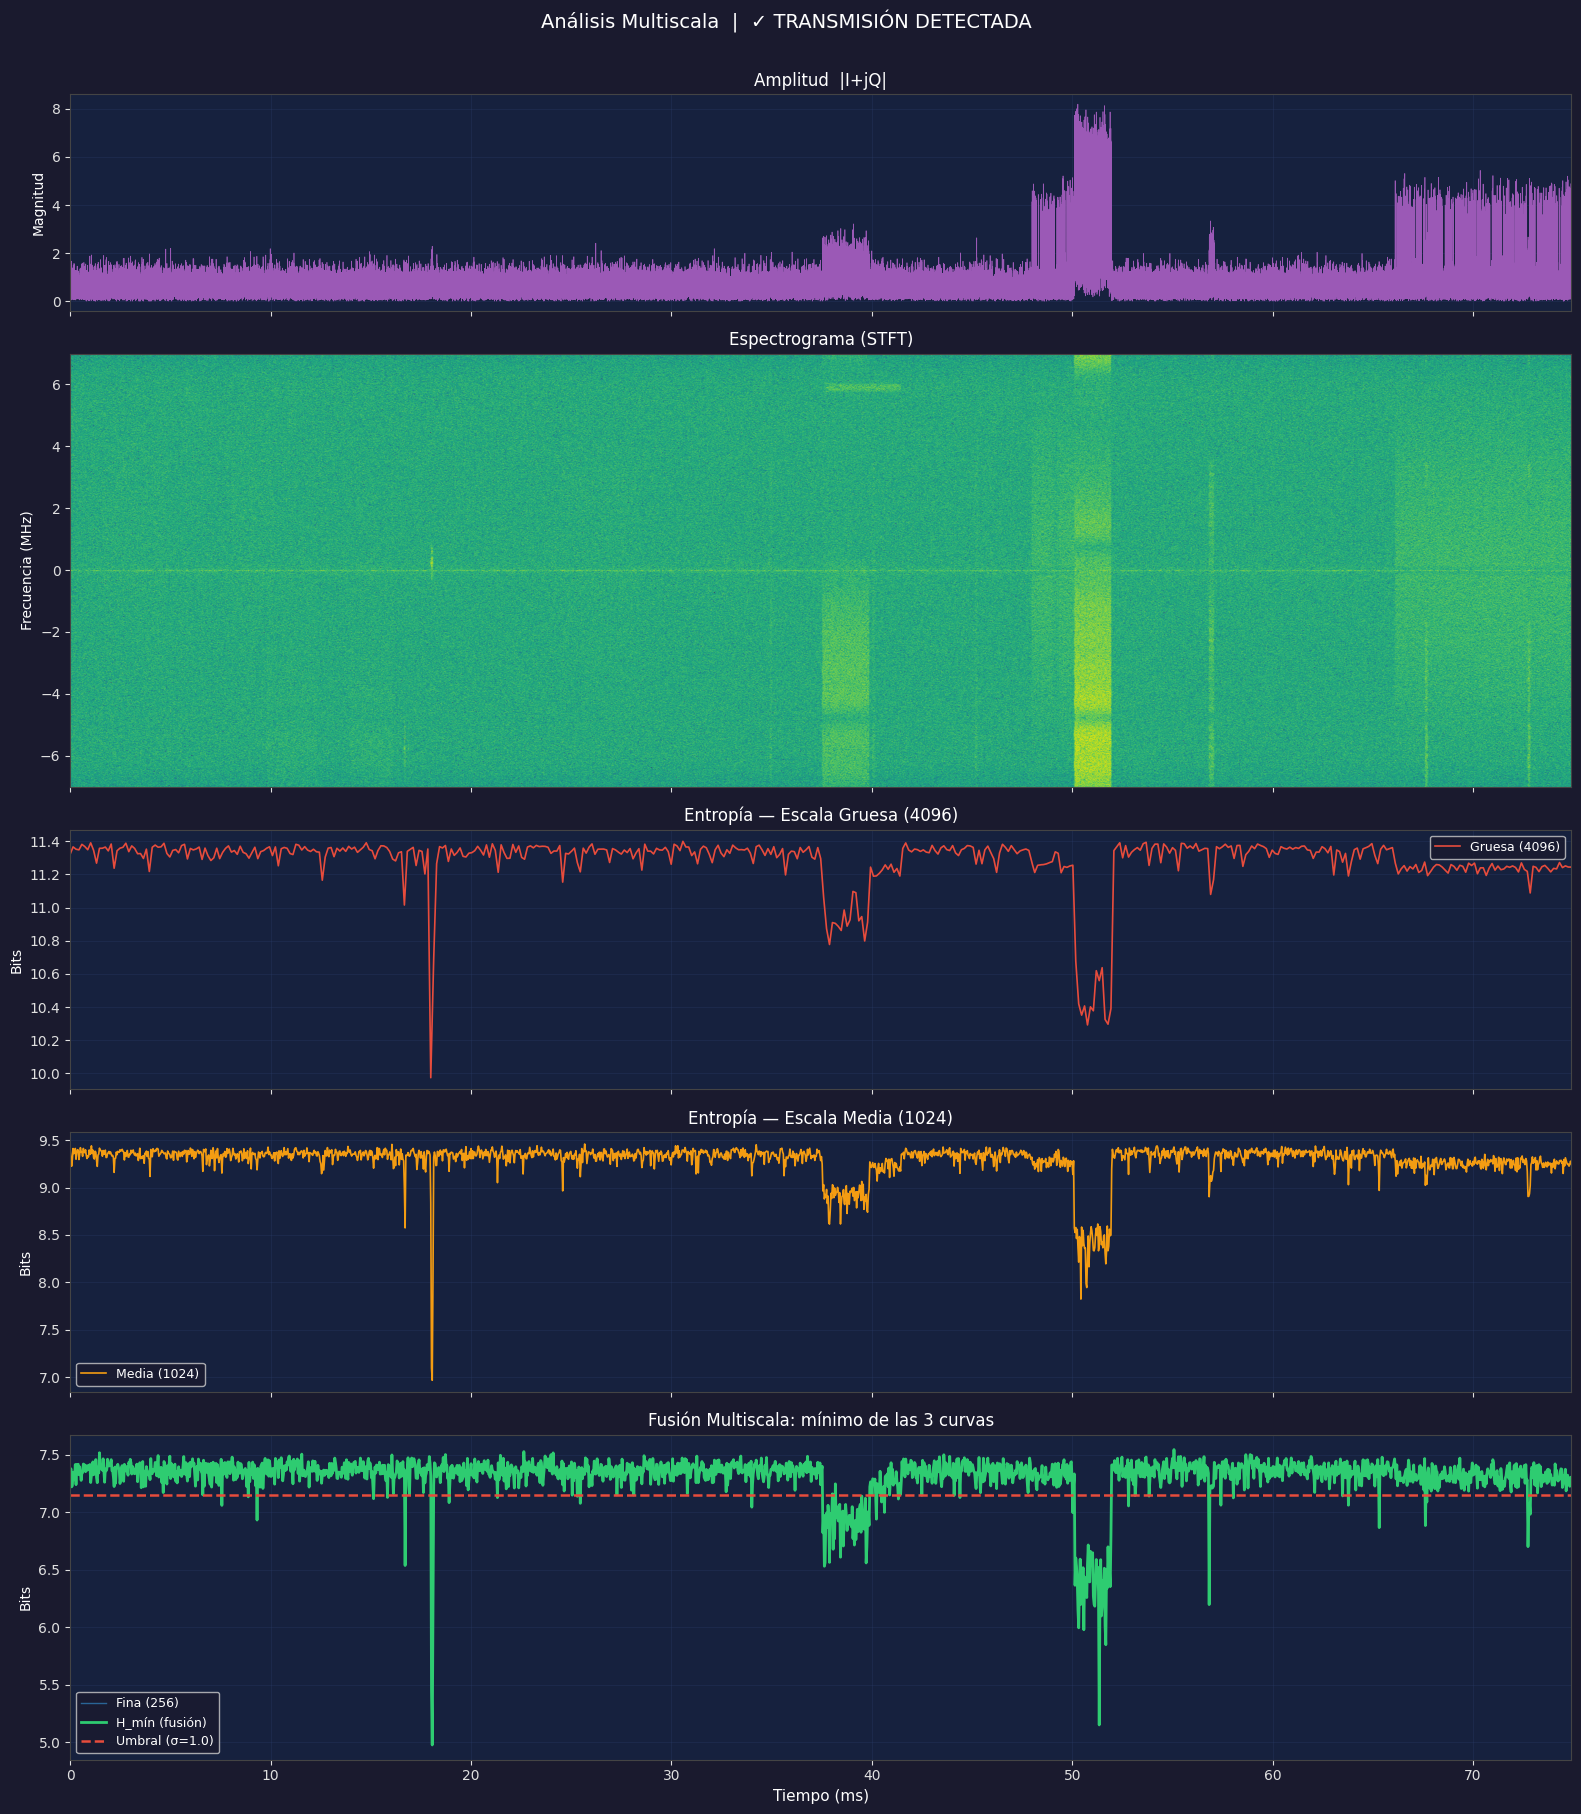

In [45]:
# Carga la muestra
iq_dron, _, _, _ = obtener_una_muestra(DATA_DIR, target=3, snr=-14, index=3)
# Calcula entropía multiscala
t_ms, H_min, H_all = detector_entropia_multiscala(iq_dron)
umbral = np.median(H_min) - 1.0 * np.std(H_min)
hay_transmision = np.any(H_min < umbral)
# Espectrograma
fs = 14e6
signal = iq_dron[0].numpy() + 1j * iq_dron[1].numpy()
f_stft, t_stft, Zxx = stft(signal, fs=fs, nperseg=1024, return_onesided=False)
f_shifted  = np.fft.fftshift(f_stft)
Zxx_shifted = np.fft.fftshift(Zxx, axes=0)
Pxx_db      = 10 * np.log10(np.abs(Zxx_shifted)**2 + 1e-12)
t_stft_ms   = t_stft * 1000
# Amplitud
amplitud = np.abs(signal)
t_amp    = np.arange(len(amplitud)) / fs * 1000
# --- Figura 5 paneles ---
plt.style.use('dark_background')
fig, axes = plt.subplots(5, 1, figsize=(16, 18), sharex=True,
                         gridspec_kw={'height_ratios': [1, 2, 1.2, 1.2, 1.5]})
fig.patch.set_facecolor('#1a1a2e')
colores = {'gruesa': '#e74c3c', 'media': '#f39c12', 'fina': '#3498db'}
for ax in axes:
    ax.set_facecolor('#16213e')
    ax.tick_params(colors='#e0e0e0')
    for spine in ax.spines.values():
        spine.set_color('#444')
# P1: Amplitud
step = 10
axes[0].plot(t_amp[::step], amplitud[::step], color='#9b59b6', lw=0.5)
axes[0].set_title('Amplitud  |I+jQ|', color='white', fontsize=12)
axes[0].set_ylabel('Magnitud', color='white')
axes[0].grid(color='#2c3e6b', alpha=0.3)
# P2: Espectrograma
axes[1].pcolormesh(t_stft_ms, f_shifted / 1e6, Pxx_db,
                   shading='gouraud', cmap='viridis')
axes[1].set_title('Espectrograma (STFT)', color='white', fontsize=12)
axes[1].set_ylabel('Frecuencia (MHz)', color='white')
# P3: Escala Gruesa
axes[2].plot(t_ms, H_all['gruesa'], color=colores['gruesa'], lw=1.2, label='Gruesa (4096)')
axes[2].set_title('Entropía — Escala Gruesa (4096)', color='white', fontsize=12)
axes[2].set_ylabel('Bits', color='white')
axes[2].legend(facecolor='#1a1a2e', labelcolor='white', fontsize=9)
axes[2].grid(color='#2c3e6b', alpha=0.3)
# P4: Escala Media
axes[3].plot(t_ms, H_all['media'], color=colores['media'], lw=1.2, label='Media (1024)')
axes[3].set_title('Entropía — Escala Media (1024)', color='white', fontsize=12)
axes[3].set_ylabel('Bits', color='white')
axes[3].legend(facecolor='#1a1a2e', labelcolor='white', fontsize=9)
axes[3].grid(color='#2c3e6b', alpha=0.3)
# P5: Fusión
axes[4].plot(t_ms, H_all['fina'], color=colores['fina'], lw=1.0, alpha=0.6, label='Fina (256)')
axes[4].plot(t_ms, H_min, color='#2ecc71', lw=2.0, label='H_mín (fusión)')
axes[4].axhline(y=umbral, color='#e74c3c', ls='--', lw=1.8, label=f'Umbral (σ=1.0)')
axes[4].set_title('Fusión Multiscala: mínimo de las 3 curvas', color='white', fontsize=12)
axes[4].set_xlabel('Tiempo (ms)', color='white', fontsize=11)
axes[4].set_ylabel('Bits', color='white')
axes[4].legend(facecolor='#1a1a2e', labelcolor='white', fontsize=9)
axes[4].grid(color='#2c3e6b', alpha=0.3)
estado = "✓ TRANSMISIÓN DETECTADA" if hay_transmision else "✗ Sin transmisión"
fig.suptitle(f'Análisis Multiscala  |  {estado}', color='white', fontsize=14, y=1.005)
plt.tight_layout()
plt.show()